# Milestone 3: Modeling & Advanced Analysis
## Week 5 & 6 - Netflix Modeling

### Objectives
1. Use clustering to group Netflix titles by genre, duration, and ratings
2. Classify content type (Movie vs. TV Show) using structured features
3. Analyze key drivers for content availability across countries and genres
4. Use feature importance methods to interpret model behavior

In [7]:
# Core imports
import ast
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import classification_report, confusion_matrix, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

print("Imports loaded.")

Imports loaded.


In [8]:
# Load enhanced dataset when available; otherwise engineer missing columns from cleaned data
try:
    df = pd.read_csv("netflix_titles_enhanced.csv")
    source_name = "netflix_titles_enhanced.csv"
except FileNotFoundError:
    df = pd.read_csv("netflix_titles_cleaned.csv")
    source_name = "netflix_titles_cleaned.csv"

if "duration_value" not in df.columns:
    df["duration_value"] = pd.to_numeric(df["duration"].str.extract(r"(\\d+)")[0], errors="coerce")

if "year_added" not in df.columns:
    parsed_date = pd.to_datetime(df["date_added"], errors="coerce")
    df["year_added"] = parsed_date.dt.year

if "month_added" not in df.columns:
    parsed_date = pd.to_datetime(df["date_added"], errors="coerce")
    df["month_added"] = parsed_date.dt.month

if "primary_country" not in df.columns:
    df["primary_country"] = df["country"].fillna("Unknown").str.split(",").str[0].str.strip()

if "genre_list_parsed" not in df.columns:
    if "genre_list" in df.columns:
        df["genre_list_parsed"] = df["genre_list"].fillna("[]")
    else:
        df["genre_list_parsed"] = df["listed_in"].fillna("").apply(lambda x: str([g.strip() for g in x.split(",") if g.strip()]))

df["genre_list_parsed"] = df["genre_list_parsed"].fillna("[]")

def parse_genres(x):
    try:
        parsed = ast.literal_eval(x) if isinstance(x, str) else x
        if isinstance(parsed, list):
            return [str(v).strip() for v in parsed if str(v).strip()]
    except Exception:
        pass
    return []

df["genres"] = df["genre_list_parsed"].apply(parse_genres)
df["primary_genre"] = df["genres"].apply(lambda g: g[0] if len(g) > 0 else "Unknown")

print(f"Loaded: {source_name}")
print(f"Shape: {df.shape}")
print("Columns ready for modeling.")

Loaded: netflix_titles_enhanced.csv
Shape: (8807, 24)
Columns ready for modeling.


## 1) Clustering Titles by Genre, Duration, and Rating

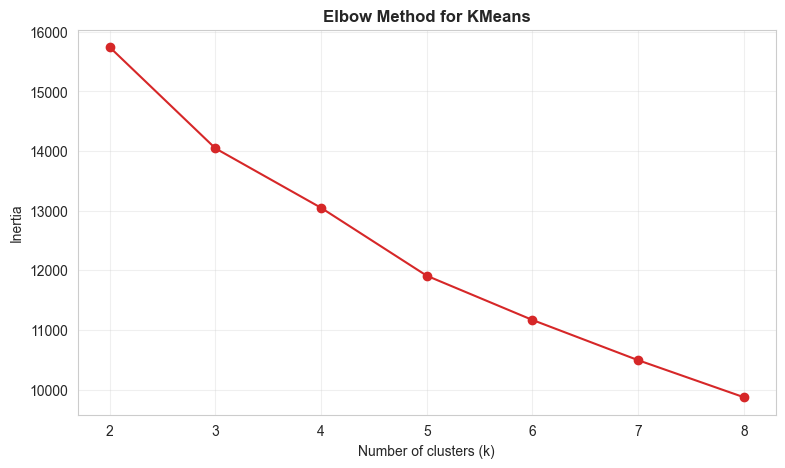

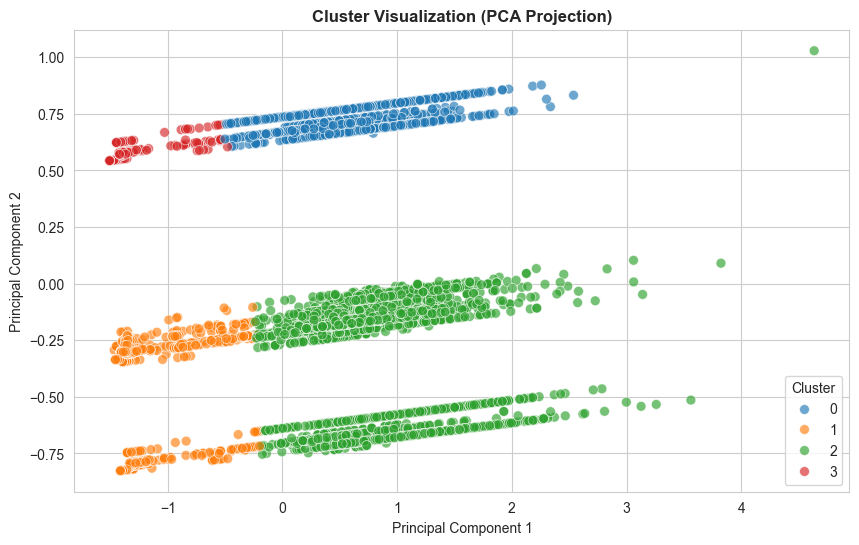

Cluster Profile:


,cluster,avg_duration,top_rating,top_genre,titles
0,0,96.979723,TV-MA,Dramas,2022
1,1,8.194280,TV-14,International TV Shows,1853
2,2,106.917223,TV-14,Dramas,3745
3,3,2.744932,TV-MA,International TV Shows,1184


In [9]:
cluster_df = df[["duration_value", "rating", "primary_genre"]].copy()
cluster_df = cluster_df.dropna(subset=["duration_value"])
cluster_df["rating"] = cluster_df["rating"].fillna("Not Rated")
cluster_df["primary_genre"] = cluster_df["primary_genre"].fillna("Unknown")

pre_cluster = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), ["duration_value"]),
        ("cat", OneHotEncoder(handle_unknown="ignore"), ["rating", "primary_genre"])
    ]
)

X_cluster = pre_cluster.fit_transform(cluster_df)

k_values = range(2, 9)
inertias = []
for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_cluster)
    inertias.append(km.inertia_)

plt.figure(figsize=(9, 5))
plt.plot(list(k_values), inertias, marker="o", color="#d62728")
plt.title("Elbow Method for KMeans", fontweight="bold")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.grid(alpha=0.3)
plt.show()

optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_df["cluster"] = kmeans.fit_predict(X_cluster)

pca = PCA(n_components=2, random_state=42)
X_vis = pca.fit_transform(X_cluster.toarray() if hasattr(X_cluster, "toarray") else X_cluster)

vis_df = pd.DataFrame({
    "pc1": X_vis[:, 0],
    "pc2": X_vis[:, 1],
    "cluster": cluster_df["cluster"].values
})

plt.figure(figsize=(10, 6))
sns.scatterplot(data=vis_df, x="pc1", y="pc2", hue="cluster", palette="tab10", alpha=0.65, s=50)
plt.title("Cluster Visualization (PCA Projection)", fontweight="bold")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")
plt.show()

cluster_profile = cluster_df.groupby("cluster").agg(
    avg_duration=("duration_value", "mean"),
    top_rating=("rating", lambda s: s.mode().iloc[0] if not s.mode().empty else "N/A"),
    top_genre=("primary_genre", lambda s: s.mode().iloc[0] if not s.mode().empty else "N/A"),
    titles=("cluster", "size")
).reset_index()

print("Cluster Profile:")
display(cluster_profile)

## 2) Classification: Movie vs TV Show

Classification Report (Movie vs TV Show):
              precision    recall  f1-score   support

       Movie       1.00      1.00      1.00      1226
     TV Show       1.00      1.00      1.00       535

    accuracy                           1.00      1761
   macro avg       1.00      1.00      1.00      1761
weighted avg       1.00      1.00      1.00      1761



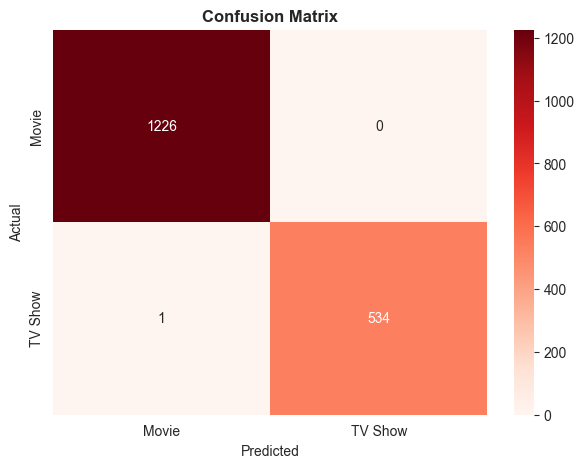

In [10]:
clf_features = [
    "release_year",
    "duration_value",
    "rating",
    "primary_country",
    "primary_genre",
    "year_added",
    "month_added"
]

clf_df = df[clf_features + ["type"]].copy()
clf_df = clf_df.dropna(subset=["type", "duration_value", "release_year"])

for col in ["rating", "primary_country", "primary_genre"]:
    clf_df[col] = clf_df[col].fillna("Unknown")

for col in ["year_added", "month_added"]:
    clf_df[col] = clf_df[col].fillna(clf_df[col].median())

X = clf_df[clf_features]
y = clf_df["type"]

num_cols = ["release_year", "duration_value", "year_added", "month_added"]
cat_cols = ["rating", "primary_country", "primary_genre"]

preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

clf_pipeline = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("model", RandomForestClassifier(n_estimators=300, random_state=42, class_weight="balanced"))
    ]
)

clf_pipeline.fit(X_train, y_train)
y_pred = clf_pipeline.predict(X_test)

print("Classification Report (Movie vs TV Show):")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred, labels=clf_pipeline.classes_)
cm_df = pd.DataFrame(cm, index=clf_pipeline.classes_, columns=clf_pipeline.classes_)

plt.figure(figsize=(7, 5))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Reds")
plt.title("Confusion Matrix", fontweight="bold")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## 3) Key Drivers of Content Availability

We estimate content availability as the number of titles per (country, genre) pair and model this count using a Random Forest Regressor.

In [14]:
drivers_df = df[["primary_country", "primary_genre", "release_year", "rating", "duration_value"]].copy()
drivers_df["primary_country"] = drivers_df["primary_country"].fillna("Unknown")
drivers_df["primary_genre"] = drivers_df["primary_genre"].fillna("Unknown")
drivers_df["rating"] = drivers_df["rating"].fillna("Not Rated")
drivers_df["duration_value"] = drivers_df["duration_value"].fillna(drivers_df["duration_value"].median())

availability = (
    drivers_df.groupby(["primary_country", "primary_genre", "rating", "release_year"], as_index=False)
    .agg(avg_duration=("duration_value", "mean"), titles_count=("duration_value", "size"))
)

X_reg = availability[["primary_country", "primary_genre", "rating", "release_year", "avg_duration"]]
y_reg = availability["titles_count"]

reg_pre = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), ["release_year", "avg_duration"]),
        ("cat", OneHotEncoder(handle_unknown="ignore"), ["primary_country", "primary_genre", "rating"])
]
)

Xr_train, Xr_test, yr_train, yr_test = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

reg_pipeline = Pipeline(
    steps=[
        ("preprocess", reg_pre),
        ("model", RandomForestRegressor(n_estimators=300, random_state=42))
    ]
)

reg_pipeline.fit(Xr_train, yr_train)
yr_pred = reg_pipeline.predict(Xr_test)

# Compute RMSE in a version-safe way across scikit-learn releases.
rmse = np.sqrt(mean_squared_error(yr_test, yr_pred))
r2 = r2_score(yr_test, yr_pred)

print(f"Driver model RMSE: {rmse:.3f}")
print(f"Driver model R2:   {r2:.3f}")

Driver model RMSE: 1.667
Driver model R2:   0.509


## 4) Feature Importance and Interpretation

Top 15 Classification Feature Importances:


,feature,importance
1,num__duration_value,0.528125
115,cat__primary_genre_International TV Shows,0.060396
111,cat__primary_genre_Dramas,0.059978
106,cat__primary_genre_Comedies,0.046126
109,cat__primary_genre_Documentaries,0.033921
116,cat__primary_genre_Kids' TV,0.028914
107,cat__primary_genre_Crime TV Shows,0.027340
99,cat__primary_genre_Action & Adventure,0.025004
103,cat__primary_genre_Children & Family Movies,0.022531
10,cat__rating_R,0.019790


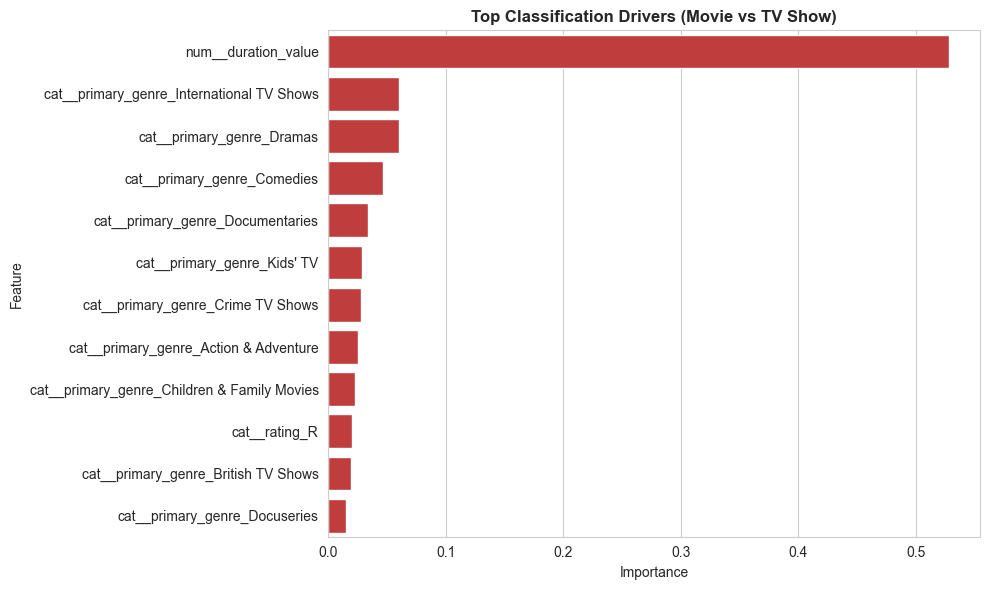

Top 15 Availability Driver Importances:


,feature,importance
0,num__release_year,0.252040
1,num__avg_duration,0.213138
132,cat__rating_TV-MA,0.079164
95,cat__primary_genre_Documentaries,0.072872
97,cat__primary_genre_Dramas,0.051712
79,cat__primary_country_United States,0.045807
130,cat__rating_TV-14,0.036163
112,cat__primary_genre_Stand-Up Comedy,0.031538
92,cat__primary_genre_Comedies,0.030882
93,cat__primary_genre_Crime TV Shows,0.018735


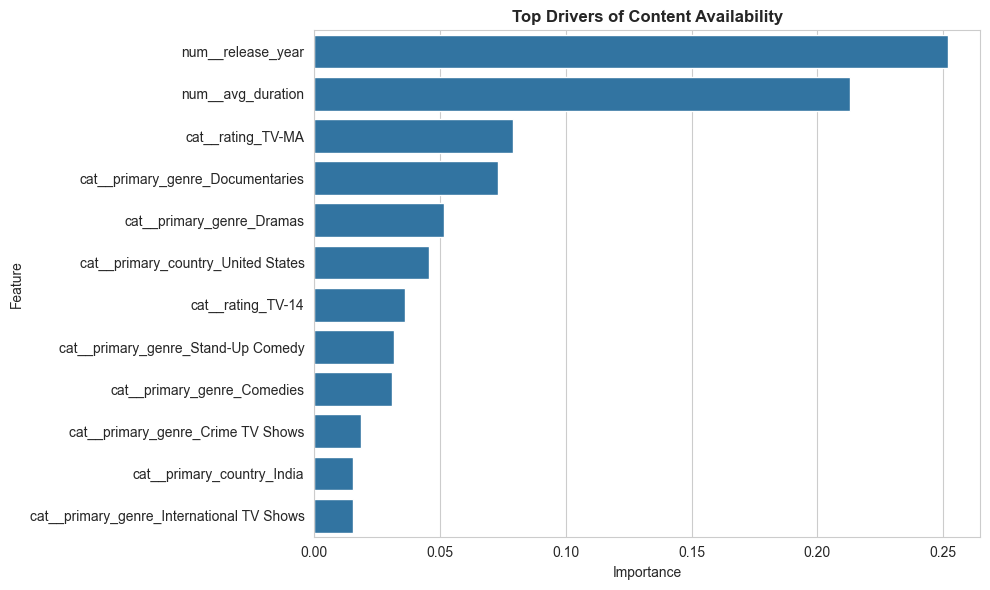

Top 10 Permutation Importances (Original Features):


,feature,perm_importance
1,duration_value,0.272345
4,primary_genre,0.118342
0,release_year,0.000000
2,rating,0.000000
3,primary_country,0.000000
5,year_added,0.000000
6,month_added,0.000000


In [ ]:
# Classification feature importance
clf_model = clf_pipeline.named_steps["model"]
clf_pre = clf_pipeline.named_steps["preprocess"]
clf_feature_names = clf_pre.get_feature_names_out()
clf_importance = pd.DataFrame({
    "feature": clf_feature_names,
    "importance": clf_model.feature_importances_
}).sort_values("importance", ascending=False)

print("Top 15 Classification Feature Importances:")
display(clf_importance.head(15))

plt.figure(figsize=(10, 6))
sns.barplot(data=clf_importance.head(12), y="feature", x="importance", color="#d62728")
plt.title("Top Classification Drivers (Movie vs TV Show)", fontweight="bold")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# Driver model feature importance
reg_model = reg_pipeline.named_steps["model"]
reg_prep = reg_pipeline.named_steps["preprocess"]
reg_feature_names = reg_prep.get_feature_names_out()
reg_importance = pd.DataFrame({
    "feature": reg_feature_names,
    "importance": reg_model.feature_importances_
}).sort_values("importance", ascending=False)

print("Top 15 Availability Driver Importances:")
display(reg_importance.head(15))

plt.figure(figsize=(10, 6))
sns.barplot(data=reg_importance.head(12), y="feature", x="importance", color="#1f77b4")
plt.title("Top Drivers of Content Availability", fontweight="bold")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# Permutation importance on classifier (Original Features)
perm = permutation_importance(clf_pipeline, X_test, y_test, n_repeats=5, random_state=42, n_jobs=-1)

perm_df = pd.DataFrame({
    "feature": X_test.columns, 
    "perm_importance": perm.importances_mean
}).sort_values("perm_importance", ascending=False)

print("Top 10 Permutation Importances (Original Features):")
display(perm_df.head(10))